<a href="https://colab.research.google.com/github/microsoftwala/CollegeFaculty/blob/main/Copy_of_Face_Detection_using_MTCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

from google.colab import files
files.upload()
import kagglehub
fareselmenshawii_face_detection_dataset_path = kagglehub.dataset_download('fareselmenshawii/face-detection-dataset')
print(fareselmenshawii_face_detection_dataset_path )
print('Data source import complete.')


Saving kaggle.json to kaggle.json


100%|██████████| 4.43G/4.43G [00:50<00:00, 93.6MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/fareselmenshawii/face-detection-dataset/versions/3
Data source import complete.


# Install and import dependencies

In [2]:
# !pip install mtcnn
import os
import zipfile

# Move kaggle.json to correct location
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download the dataset
!kaggle datasets download -d fareselmenshawii/face-detection-dataset

# Unzip the downloaded dataset
!unzip face-detection-dataset.zip -d face_detection_dataset

Streaming output truncated to the last 5000 lines.
  inflating: face_detection_dataset/labels2/b0a96b76a58c433c.txt  
  inflating: face_detection_dataset/labels2/b0abd92b73ecb406.txt  
  inflating: face_detection_dataset/labels2/b0b880a17aeb2905.txt  
  inflating: face_detection_dataset/labels2/b0b9a9952976e42b.txt  
  inflating: face_detection_dataset/labels2/b0bfe0f426275870.txt  
  inflating: face_detection_dataset/labels2/b0c2f74e1fed9b71.txt  
  inflating: face_detection_dataset/labels2/b0c4491f61005387.txt  
  inflating: face_detection_dataset/labels2/b0c4ccd19b83f4c6.txt  
  inflating: face_detection_dataset/labels2/b0c66e943f050df1.txt  
  inflating: face_detection_dataset/labels2/b0c9eb2a1f9aa986.txt  
  inflating: face_detection_dataset/labels2/b0cf4af0df03be90.txt  
  inflating: face_detection_dataset/labels2/b0d51a66b2c3abeb.txt  
  inflating: face_detection_dataset/labels2/b0d9501aa2380861.txt  
  inflating: face_detection_dataset/labels2/b0d97c088f04e8b1.txt  
  inflating

# Data Visualiation

In [14]:
# IMAGES = '/kaggle/input/face-detection-dataset/images'
# LABELS = '/kaggle/input/face-detection-dataset/labels'
# !unzip face-detection-dataset.zip -d face_detection_dataset

# !pip install mtcnn

import os
import cv2
from mtcnn import MTCNN
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from google.colab import files
from tqdm import tqdm


# Correct the paths to the images and labels
IMAGES = 'face_detection_dataset/images'
LABELS = 'face_detection_dataset/labels'

images = os.listdir(os.path.join(IMAGES,'train'))
labels = os.listdir(os.path.join(LABELS,'train'))

# print(images)


# New Section

In [4]:
img = os.path.join(IMAGES,'train',images[1])
lbl = os.path.join(LABELS,'train',images[1][:-3]+'txt')


In [5]:
def show_img_lbls(image_path, label_path):
    image = cv2.imread(image_path)
    height, width = image.shape[:2]
    with open(label_path, 'r') as f:
        lines = f.read()
    lines = [x for x in lines.split('\n') if len(x)>0]
    objs = []
    for i in lines:
        i = i.split(' ')
        objs.append([int(i[0]), float(i[1]), float(i[2]), float(i[3]), float(i[4])])
    for i,obj in enumerate(objs):
        x_min = int(obj[1]*width - obj[3]*width/2)
        x_max = int(obj[1]*width + obj[3]*width/2)

        y_min = int(obj[2]*height - obj[4]*height/2)
        y_max = int(obj[2]*height + obj[4]*height/2)
#         print(x_min, y_min, x_max, y_max)
        image = cv2.rectangle(image,(x_min,y_min),(x_max, y_max),(0,255,0),2)
    plt.imshow(image[:,:,::-1])

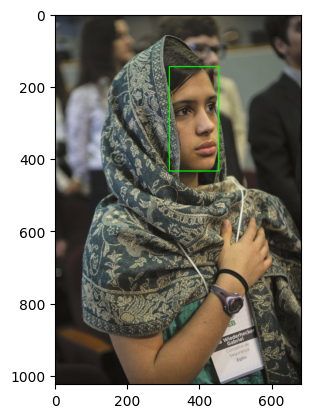

In [6]:
show_img_lbls(img,lbl)

# Using MTCNN

Processing images with MTCNN:   0%|          | 0/13386 [00:00<?, ?it/s]

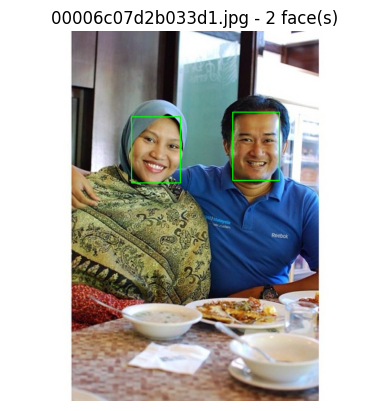

Processing images with MTCNN:   0%|          | 1/13386 [00:01<4:19:00,  1.16s/it]

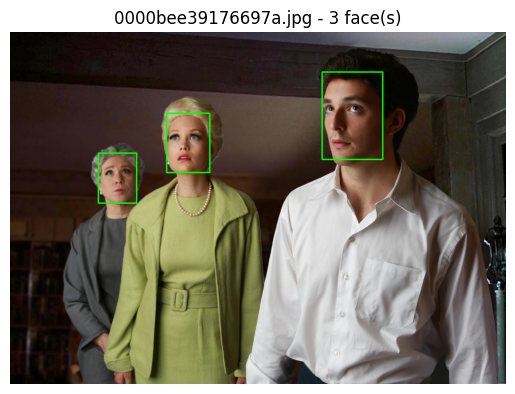

Processing images with MTCNN:   0%|          | 2/13386 [00:01<3:09:25,  1.18it/s]

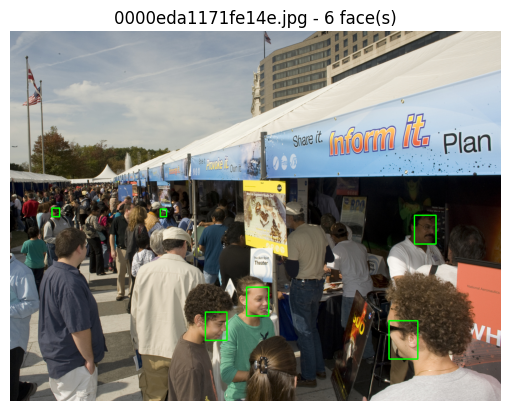

Processing images with MTCNN:   0%|          | 3/13386 [00:02<3:01:03,  1.23it/s]

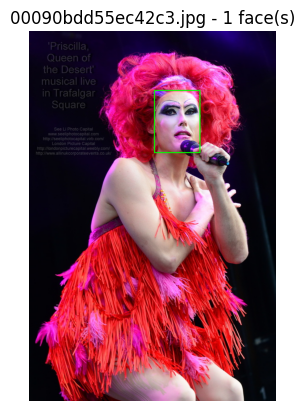

Processing images with MTCNN:   0%|          | 4/13386 [00:03<2:40:17,  1.39it/s]

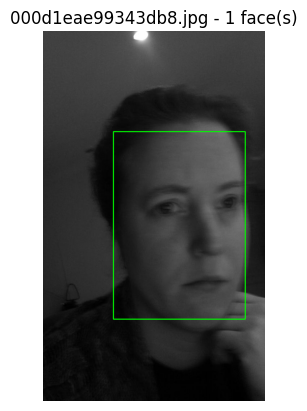

Processing images with MTCNN:   0%|          | 5/13386 [00:03<2:18:16,  1.61it/s]

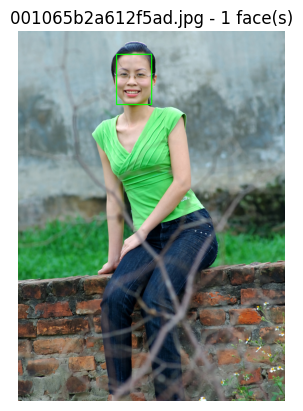

Processing images with MTCNN:   0%|          | 6/13386 [00:04<2:24:28,  1.54it/s]

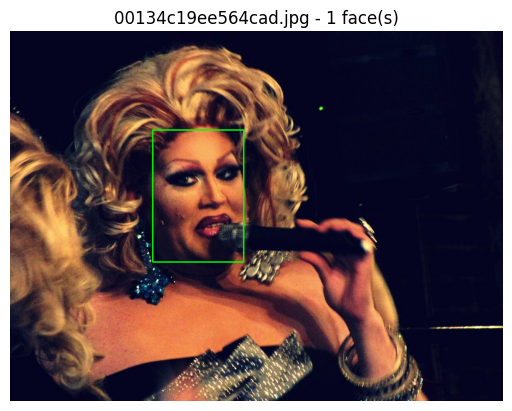

Processing images with MTCNN:   0%|          | 7/13386 [00:05<2:31:26,  1.47it/s]

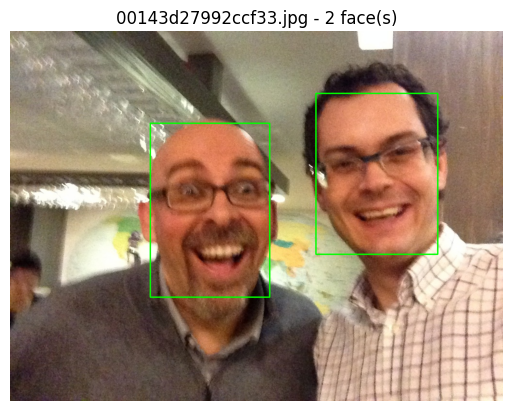

Processing images with MTCNN:   0%|          | 8/13386 [00:05<2:33:50,  1.45it/s]

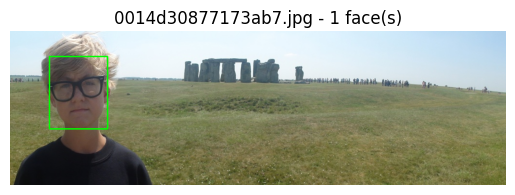

Processing images with MTCNN:   0%|          | 9/13386 [00:06<2:12:36,  1.68it/s]

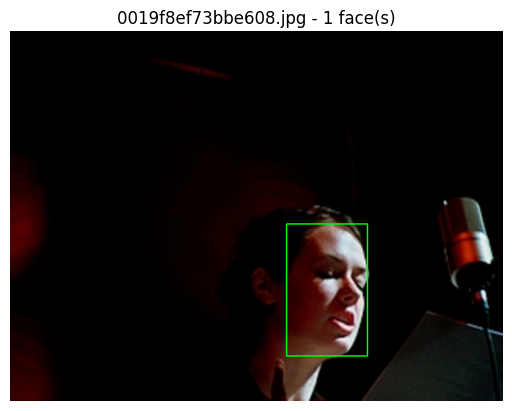

Processing images with MTCNN:   0%|          | 10/13386 [00:06<2:11:28,  1.70it/s]

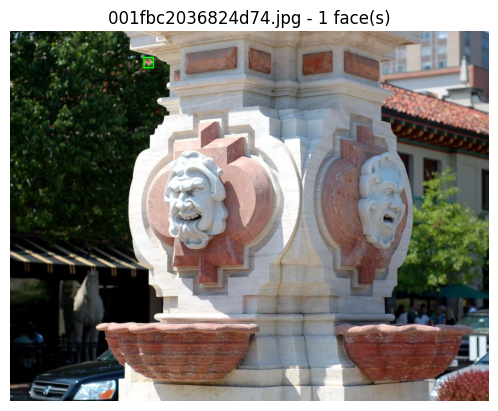

Processing images with MTCNN:   0%|          | 11/13386 [00:07<2:36:38,  1.42it/s]

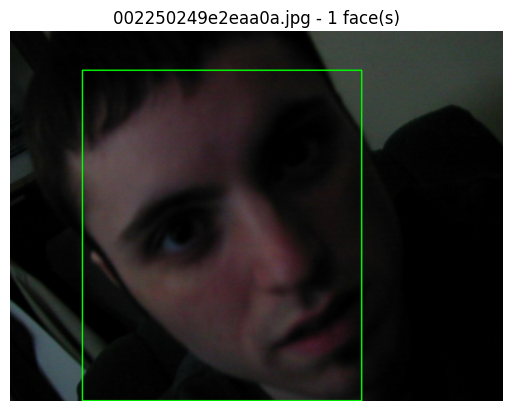

Processing images with MTCNN:   0%|          | 12/13386 [00:08<2:50:55,  1.30it/s]

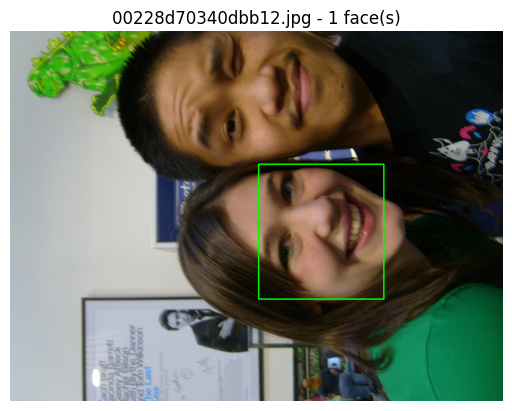

Processing images with MTCNN:   0%|          | 13/13386 [00:09<3:06:12,  1.20it/s]

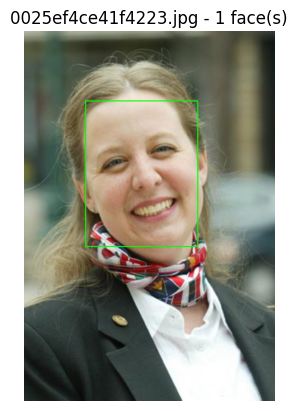

Processing images with MTCNN:   0%|          | 14/13386 [00:10<2:51:01,  1.30it/s]


KeyboardInterrupt: 

In [15]:

IMAGES_DIR = 'face_detection_dataset/images/train'
LABELS_DIR = 'face_detection_dataset/labels/train'

# List of image files
image_files = sorted(os.listdir(IMAGES_DIR))

# Initialize MTCNN
detector = MTCNN()

# Loop over images with progress bar
for image_file in tqdm(image_files, desc="Processing images with MTCNN"):
    # Construct full image path
    img_path = os.path.join(IMAGES_DIR, image_file)
    # adjust extension if needed
    label_path = os.path.join(LABELS_DIR, image_file.replace(".jpg", ".txt"))

    # Read and convert image
    image = cv2.imread(img_path)
    if image is None:
        print(f"Failed to read {img_path}")
        continue

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Detect faces
    faces = detector.detect_faces(image_rgb)

    # Print detections
    # print(f"{image_file}: Detected {len(faces)} face(s)")

    #  Draw detections
    for face in faces:
        x, y, w, h = face['box']
        cv2.rectangle(image_rgb, (x, y), (x+w, y+h), (0, 255, 0), 2)

    # (Optional) Show sample results
    plt.imshow(image_rgb)
    plt.title(f"{image_file} - {len(faces)} face(s)")
    plt.axis('off')
    plt.show()


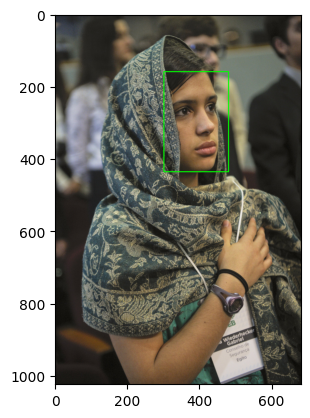

In [16]:
image = cv2.cvtColor(cv2.imread(img), cv2.COLOR_BGR2RGB)
detector = MTCNN()
res = detector.detect_faces(image)
faces = len(res)
for face in res:
    image = cv2.rectangle(image, face['box'][:2], (face['box'][0] + face['box'][2], face['box'][1] + face['box'][3]), (0, 255, 0), 2)
plt.imshow(image)

In [13]:
# Upload image
from google.colab import files
uploaded = files.upload()

# Get the uploaded file name
image_path = next(iter(uploaded))
# print(image)

Saving 453456.jpg to 453456.jpg


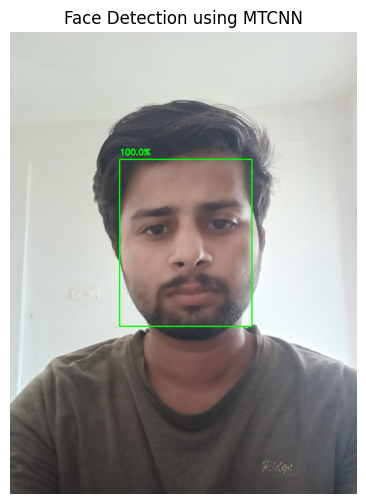

In [14]:
# Open and convert image to RGB
from PIL import Image
import numpy as np
from mtcnn import MTCNN
import cv2
import matplotlib.pyplot as plt


image = Image.open(image_path).convert('RGB')
img_rgb = np.array(image)

# Convert to BGR for OpenCV compatibility (if needed)
img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)

# Initialize MTCNN detector
detector = MTCNN()

# Detect faces
faces = detector.detect_faces(img_rgb)

# Draw bounding boxes
for face in faces:
    x, y, w, h = face['box']
    cv2.rectangle(img_rgb, (x, y), (x + w, y + h), (0, 255, 0), 2)
    confidence = round(face['confidence'] * 100, 2)
    cv2.putText(img_rgb, f'{confidence}%', (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

# Display result
plt.figure(figsize=(8, 6))
plt.imshow(img_rgb)
plt.axis('off')
plt.title("Face Detection using MTCNN")
plt.show()
